# Final Keystone Project

### 5.1 Import Key Libraries and Datasets

In [19]:
import pandas as pd
import numpy as np

In [3]:
JPM_df = pd.read_csv('JPM.csv')
JPM_df

,Date,Open,High,Low,Close,Adj Close,Volume
0,7/14/2017,90.809998,92.610001,90.580002,92.250000,79.338943,22235200
1,7/17/2017,91.820000,91.989998,91.250000,91.389999,78.599312,14374200
2,7/18/2017,90.449997,91.580002,90.320000,91.070000,78.324104,14719400
3,7/19/2017,91.339996,91.620003,91.000000,91.199997,78.435898,11651200
4,7/20/2017,91.150002,91.720001,90.900002,91.199997,78.435898,11561700
...,...,...,...,...,...,...,...
1363,12/12/2022,132.399994,134.649994,131.600006,134.210007,134.210007,8841600
1364,12/13/2022,136.889999,137.089996,133.080002,134.080002,134.080002,10025400
1365,12/14/2022,133.779999,135.710007,132.759995,133.410004,133.410004,9966100
1366,12/15/2022,131.149994,132.080002,129.050003,130.100006,130.100006,12087800


In [4]:
JPM_df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [5]:
JPM_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1368 entries, 0 to 1367
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1368 non-null   str    
 1   Open       1368 non-null   float64
 2   High       1368 non-null   float64
 3   Low        1368 non-null   float64
 4   Close      1368 non-null   float64
 5   Adj Close  1368 non-null   float64
 6   Volume     1368 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 74.9 KB


### 5.2 Calculate Percentage Daily Returns

In [6]:
JPM_df['Daily Returns'] = JPM_df['Adj Close'].pct_change(1)*100
JPM_df

,Date,Open,High,Low,Close,Adj Close,Volume,Daily Returns
0,7/14/2017,90.809998,92.610001,90.580002,92.250000,79.338943,22235200,NaN
1,7/17/2017,91.820000,91.989998,91.250000,91.389999,78.599312,14374200,-0.932243
2,7/18/2017,90.449997,91.580002,90.320000,91.070000,78.324104,14719400,-0.350140
3,7/19/2017,91.339996,91.620003,91.000000,91.199997,78.435898,11651200,0.142732
4,7/20/2017,91.150002,91.720001,90.900002,91.199997,78.435898,11561700,0.000000
...,...,...,...,...,...,...,...,...
1363,12/12/2022,132.399994,134.649994,131.600006,134.210007,134.210007,8841600,1.551152
1364,12/13/2022,136.889999,137.089996,133.080002,134.080002,134.080002,10025400,-0.096867
1365,12/14/2022,133.779999,135.710007,132.759995,133.410004,133.410004,9966100,-0.499700
1366,12/15/2022,131.149994,132.080002,129.050003,130.100006,130.100006,12087800,-2.481072


In [7]:
JPM_df['Daily Returns'].max()

np.float64(18.012495662164163)

### 5.3 Data Visulaisation for Single Stock pt1

In [25]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns


JPM_df['Date'] = pd.to_datetime(JPM_df['Date'])

print("Pandas:", pd.__version__)

Pandas: 3.0.5


In [41]:
def plot_financial_data(df, title):
    
    plt.figure(figsize=(14, 6))

    for col in df.columns:
        if col != 'Date':
            plt.plot(
                df['Date'],
                df[col],
                label=col,
                linewidth=1
            )

    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Price [$]')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
    
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

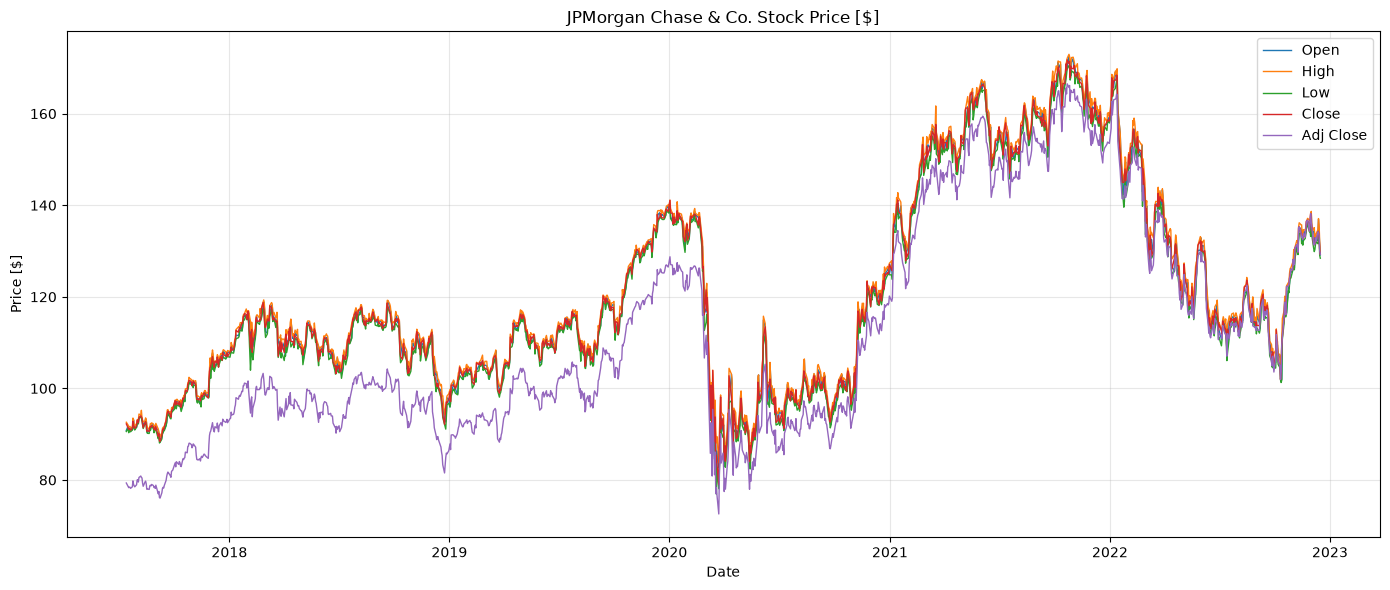

In [10]:
plot_financial_data(
    JPM_df.drop(['Volume', 'Daily Returns'], axis=1),
    'JPMorgan Chase & Co. Stock Price [$]'
)

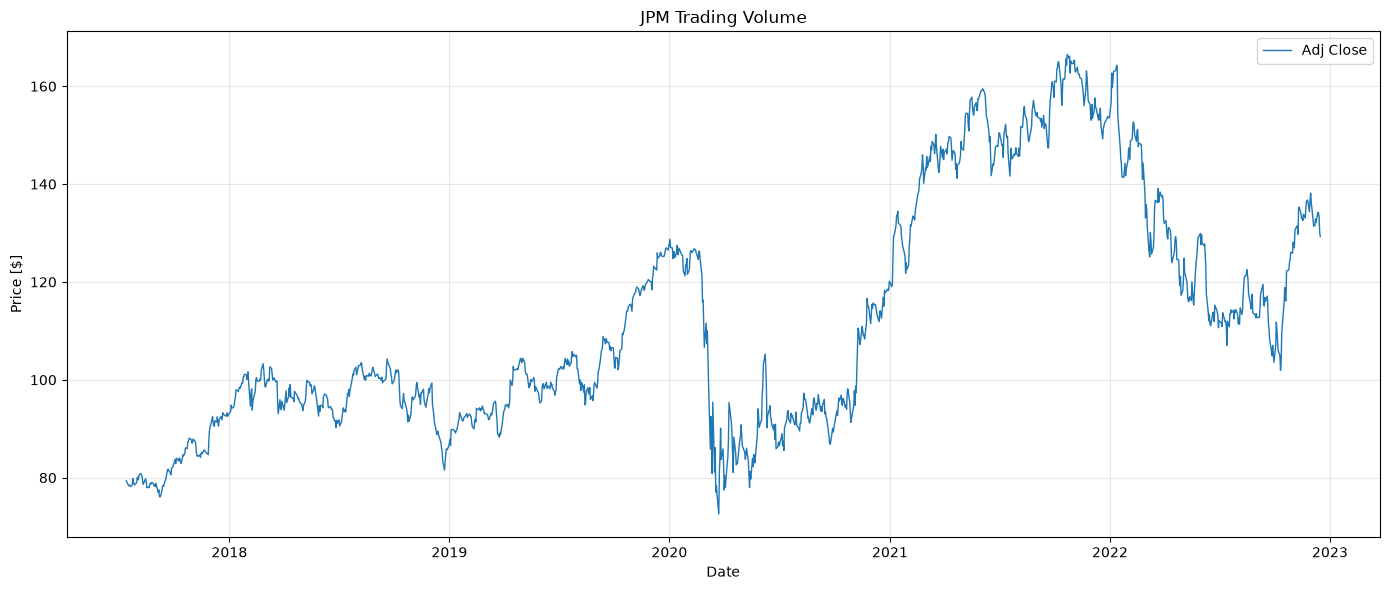

In [11]:
plot_financial_data(JPM_df.iloc[:,[0,5]], 'JPM Trading Volume')

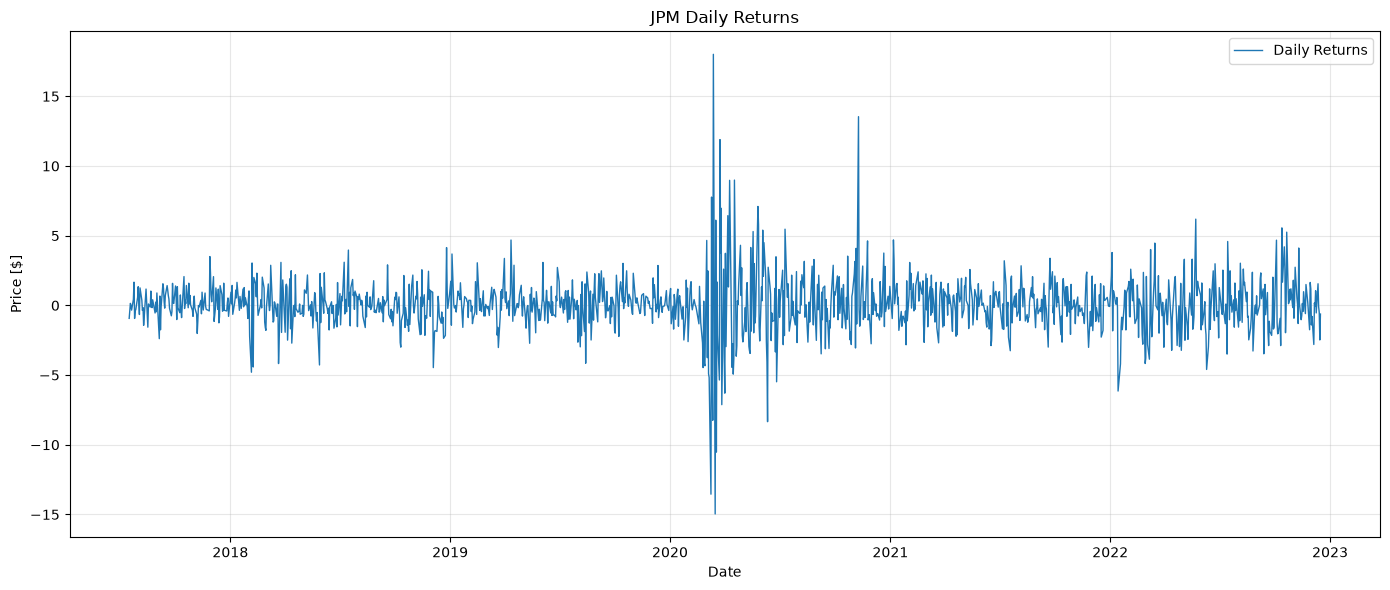

In [12]:
plot_financial_data(JPM_df.iloc[:, [0,7]], 'JPM Daily Returns')

### 5.4 Visualisation pt2

In [13]:
def percentage_return_classifier(percentage_return):
    
    if percentage_return > -0.3 and percentage_return <= 0.3:
        return 'Insignificant Change'
    elif percentage_return > 0.3 and percentage_return <= 3:
        return 'Positive Change'
    elif percentage_return > -3 and percentage_return <= -0.3:
        return 'Negative Change'
    elif percentage_return > 3 and percentage_return <= 7:
        return 'Large Positive Change'
    elif percentage_return > -7 and percentage_return <= -3:
        return 'Large Negative Change'
    elif percentage_return > 7:
        return 'Bull Run'
    elif percentage_return <= -7:
        return 'Bear Sell Off'

In [14]:
JPM_df['Trend'] = JPM_df['Daily Returns'].apply(percentage_return_classifier)
JPM_df

,Date,Open,High,Low,Close,Adj Close,Volume,Daily Returns,Trend
0,2017-07-14,90.809998,92.610001,90.580002,92.250000,79.338943,22235200,NaN,NaN
1,2017-07-17,91.820000,91.989998,91.250000,91.389999,78.599312,14374200,-0.932243,Negative Change
2,2017-07-18,90.449997,91.580002,90.320000,91.070000,78.324104,14719400,-0.350140,Negative Change
3,2017-07-19,91.339996,91.620003,91.000000,91.199997,78.435898,11651200,0.142732,Insignificant Change
4,2017-07-20,91.150002,91.720001,90.900002,91.199997,78.435898,11561700,0.000000,Insignificant Change
...,...,...,...,...,...,...,...,...,...
1363,2022-12-12,132.399994,134.649994,131.600006,134.210007,134.210007,8841600,1.551152,Positive Change
1364,2022-12-13,136.889999,137.089996,133.080002,134.080002,134.080002,10025400,-0.096867,Insignificant Change
1365,2022-12-14,133.779999,135.710007,132.759995,133.410004,133.410004,9966100,-0.499700,Negative Change
1366,2022-12-15,131.149994,132.080002,129.050003,130.100006,130.100006,12087800,-2.481072,Negative Change


In [15]:
trend_summary = JPM_df['Trend'].value_counts()
trend_summary

Trend
Positive Change          501
Negative Change          495
Insignificant Change     261
Large Positive Change     53
Large Negative Change     44
Bull Run                   7
Bear Sell Off              6
Name: count, dtype: int64

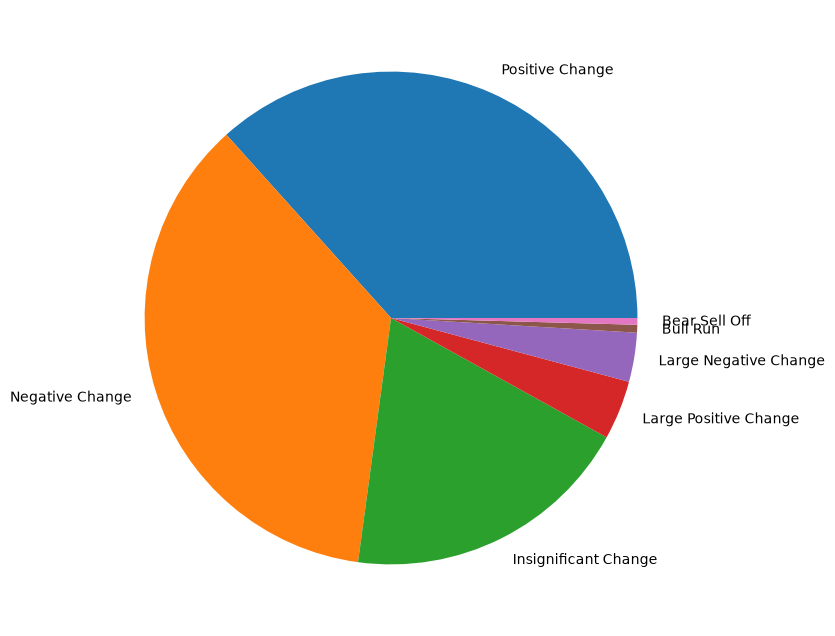

In [16]:
plt.figure(figsize = (8, 8))
trend_summary.plot(kind = 'pie', y = 'Trend');

### 5.5 (Candlestick Deprecated Library)

### 5.6 Multiple Stocks Visualisation

In [17]:
close_price_df = pd.read_csv('stock_prices.csv')
close_price_df

,Date,AMZN,CAT,DE,EXC,GOOGL,JNJ,JPM,META,PFE,PG
0,1/2/2014,19.898500,69.512543,75.620926,14.121004,27.855856,71.443314,45.640057,54.709999,20.879053,61.941517
1,1/3/2014,19.822001,69.473892,75.956062,13.835152,27.652653,72.086861,45.992889,54.560001,20.920183,61.872295
2,1/6/2014,19.681499,68.561180,75.327690,13.923512,27.960960,72.463608,46.259468,57.200001,20.940746,62.018425
3,1/7/2014,19.901501,68.785461,75.662811,13.996271,28.500000,74.001869,45.726311,57.919998,21.070980,62.618301
4,1/8/2014,20.096001,68.947906,74.850121,13.965082,28.559309,73.899841,46.157543,58.230000,21.214928,61.710812
...,...,...,...,...,...,...,...,...,...,...,...
2252,12/12/2022,90.550003,233.059998,437.049988,42.500000,93.309998,177.839996,134.210007,114.709999,52.160000,152.470001
2253,12/13/2022,92.489998,235.490005,437.190002,42.540001,95.629997,179.210007,134.080002,120.150002,53.070000,152.240005
2254,12/14/2022,91.580002,234.479996,438.440002,42.820000,95.070000,179.759995,133.410004,121.589996,54.480000,152.839996
2255,12/15/2022,88.449997,230.660004,429.790008,42.380001,90.860001,177.490005,130.100006,116.150002,53.610001,151.110001


In [20]:
daily_returns_df = close_price_df.iloc[:, 1:].pct_change() * 100
daily_returns_df.replace(np.nan, 0, inplace=True)
daily_returns_df

,AMZN,CAT,DE,EXC,GOOGL,JNJ,JPM,META,PFE,PG
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,-0.384451,-0.055602,0.443179,-2.024307,-0.729481,0.900780,0.773077,-0.274169,0.196992,-0.111753
2,-0.708814,-1.313748,-0.827284,0.638662,1.114930,0.522629,0.579608,4.838708,0.098293,0.236179
3,1.117807,0.327126,0.444884,0.522567,1.927829,2.122805,-1.152537,1.258737,0.621916,0.967255
4,0.977313,0.236162,-1.074095,-0.222838,0.208102,-0.137872,0.943073,0.535223,0.683156,-1.449240
...,...,...,...,...,...,...,...,...,...,...
2252,1.638800,2.538609,0.515165,2.607441,0.517070,1.194942,1.551152,-1.026749,0.850732,1.027036
2253,2.142457,1.042653,0.032036,0.094120,2.486336,0.770361,-0.096867,4.742396,1.744632,-0.150847
2254,-0.983886,-0.428897,0.285917,0.658201,-0.585588,0.306896,-0.499700,1.198498,2.656868,0.394108
2255,-3.417782,-1.629133,-1.972903,-1.027554,-4.428315,-1.262789,-2.481072,-4.474048,-1.596914,-1.131900


In [29]:
daily_returns_df.insert(0, "Date", close_price_df['Date'])
daily_returns_df

ValueError: cannot insert Date, already exists

In [32]:
daily_returns_df['Date'] = pd.to_datetime(daily_returns_df['Date'])
close_price_df['Date'] = pd.to_datetime(close_price_df['Date'])


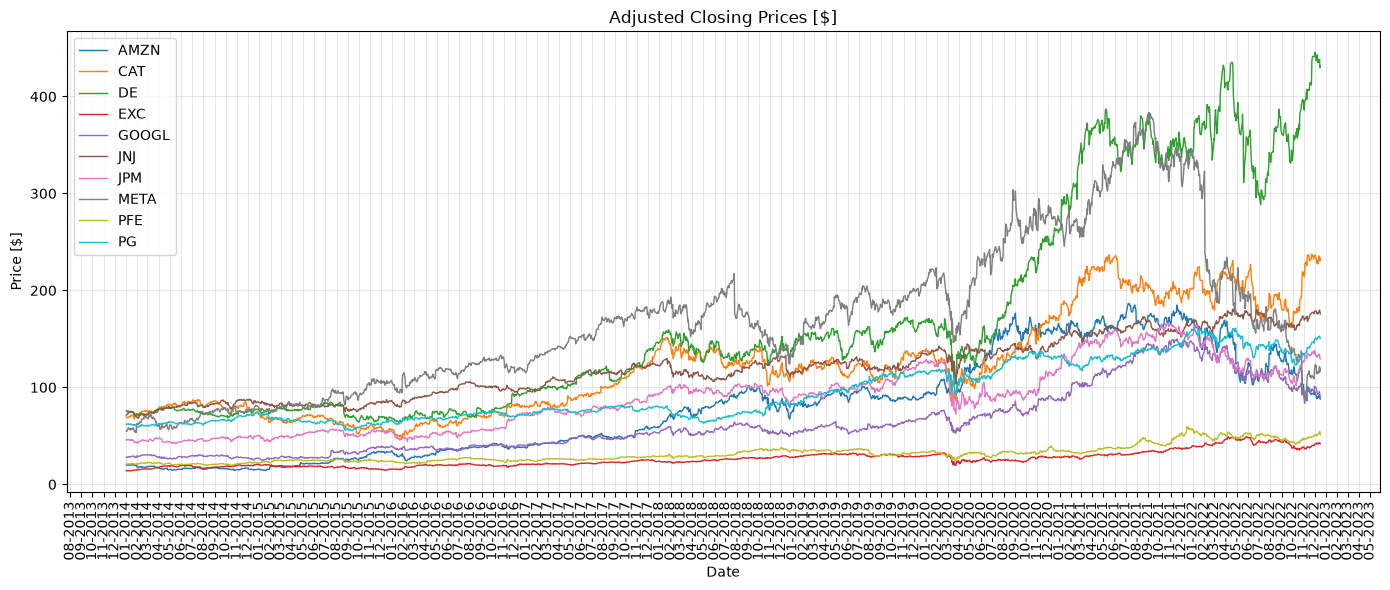

In [42]:
plot_financial_data(close_price_df, 'Adjusted Closing Prices [$]')

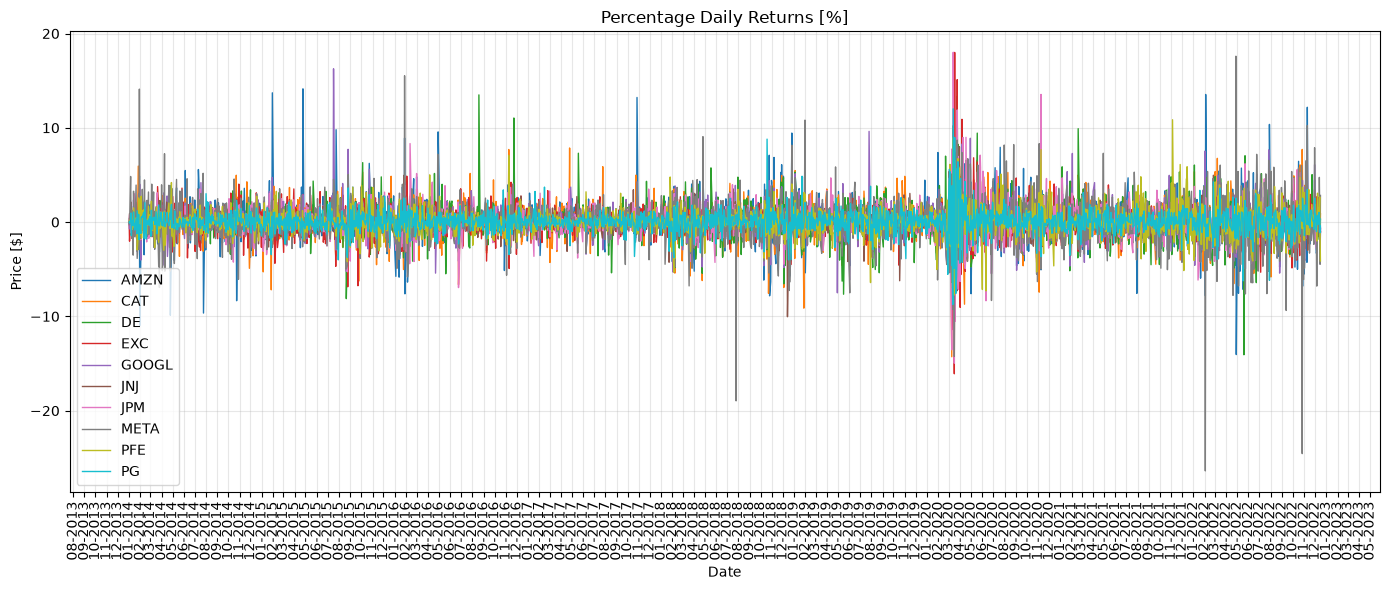

In [43]:
plot_financial_data(daily_returns_df, 'Percentage Daily Returns [%]')

In [45]:
def price_scaling(raw_prices_df):
    scaled_prices_df = raw_prices_df.copy()
    for i in raw_prices_df.columns[1:]:
        scaled_prices_df[i] = raw_prices_df[i]/raw_prices_df[i][0]
    return scaled_prices_df

In [46]:
price_scaling(close_price_df)

,Date,AMZN,CAT,DE,EXC,GOOGL,JNJ,JPM,META,PFE,PG
0,2014-01-02,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,2014-01-03,0.996155,0.999444,1.004432,0.979757,0.992705,1.009008,1.007731,0.997258,1.001970,0.998882
2,2014-01-06,0.989095,0.986314,0.996122,0.986014,1.003773,1.014281,1.013572,1.045513,1.002955,1.001242
3,2014-01-07,1.000151,0.989540,1.000554,0.991167,1.023124,1.035812,1.001890,1.058673,1.009192,1.010926
4,2014-01-08,1.009925,0.991877,0.989807,0.988958,1.025253,1.034384,1.011338,1.064339,1.016087,0.996275
...,...,...,...,...,...,...,...,...,...,...,...
2252,2022-12-12,4.550594,3.352776,5.779485,3.009701,3.349744,2.489246,2.940619,2.096692,2.498198,2.461515
2253,2022-12-13,4.648089,3.387734,5.781336,3.012534,3.433030,2.508422,2.937770,2.196125,2.541782,2.457802
2254,2022-12-14,4.602357,3.373204,5.797866,3.032362,3.412927,2.516121,2.923090,2.222446,2.609314,2.467489
2255,2022-12-15,4.445058,3.318250,5.683480,3.001203,3.261792,2.484347,2.850566,2.123012,2.567645,2.439559


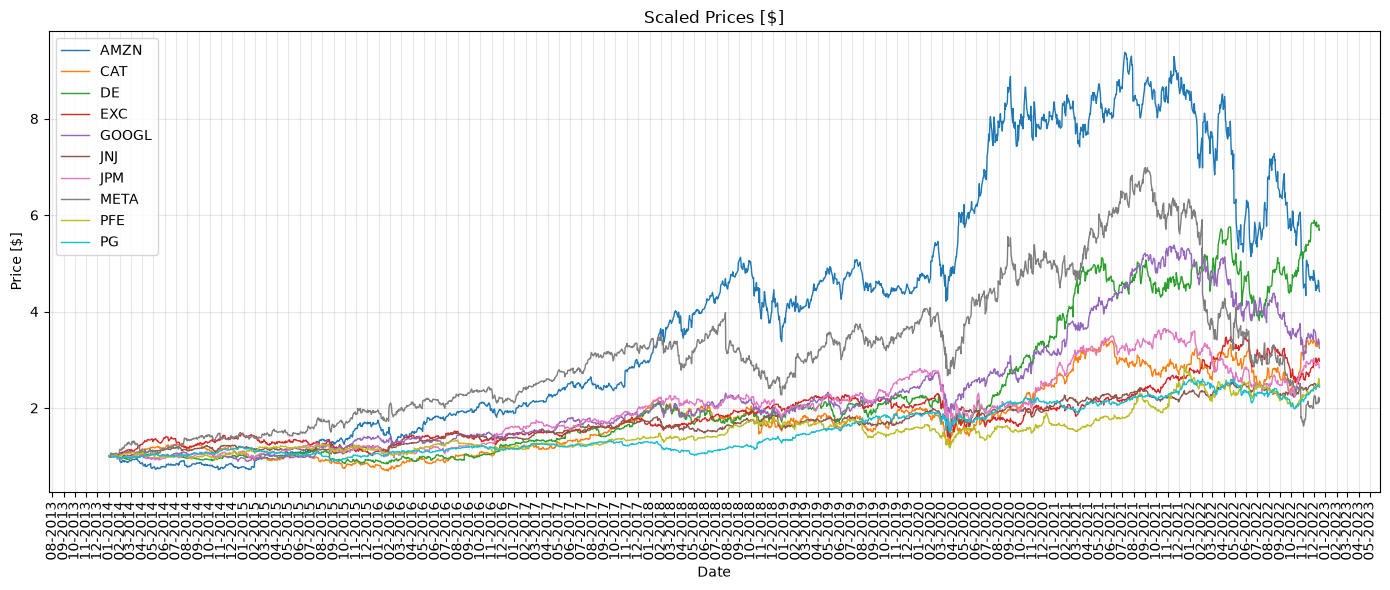

In [47]:
plot_financial_data(price_scaling(close_price_df), 'Scaled Prices [$]')

### 5.7 Random Portfolio Weights Generation

In [48]:
import random

def generate_portfolio_weights(n):
    weights = []
    for i in range(n):
        weights.append(random.random())
        
    weights = weights/np.sum(weights)
    return weights

In [51]:
weights = generate_portfolio_weights(10)
print(weights)
print(weights.sum())


[0.12668236 0.03623199 0.07976053 0.08818437 0.11146152 0.10732049
 0.11493754 0.09915816 0.10235397 0.13390906]
1.0


### 5.8 Asset Allocation

In [52]:
portfolio_df = close_price_df.copy()
scaled_df = price_scaling(portfolio_df)
scaled_df

,Date,AMZN,CAT,DE,EXC,GOOGL,JNJ,JPM,META,PFE,PG
0,2014-01-02,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,2014-01-03,0.996155,0.999444,1.004432,0.979757,0.992705,1.009008,1.007731,0.997258,1.001970,0.998882
2,2014-01-06,0.989095,0.986314,0.996122,0.986014,1.003773,1.014281,1.013572,1.045513,1.002955,1.001242
3,2014-01-07,1.000151,0.989540,1.000554,0.991167,1.023124,1.035812,1.001890,1.058673,1.009192,1.010926
4,2014-01-08,1.009925,0.991877,0.989807,0.988958,1.025253,1.034384,1.011338,1.064339,1.016087,0.996275
...,...,...,...,...,...,...,...,...,...,...,...
2252,2022-12-12,4.550594,3.352776,5.779485,3.009701,3.349744,2.489246,2.940619,2.096692,2.498198,2.461515
2253,2022-12-13,4.648089,3.387734,5.781336,3.012534,3.433030,2.508422,2.937770,2.196125,2.541782,2.457802
2254,2022-12-14,4.602357,3.373204,5.797866,3.032362,3.412927,2.516121,2.923090,2.222446,2.609314,2.467489
2255,2022-12-15,4.445058,3.318250,5.683480,3.001203,3.261792,2.484347,2.850566,2.123012,2.567645,2.439559


In [53]:
initial_investment = 1000000
for i, stock in enumerate(scaled_df.columns[1:]):
    portfolio_df[stock] = weights[i] * scaled_df[stock] * initial_investment
    
portfolio_df.round()

C:\Users\a00563576\AppData\Local\Temp\ipykernel_18608\2932144991.py:5: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  portfolio_df.round()


,Date,AMZN,CAT,DE,EXC,GOOGL,JNJ,JPM,META,PFE,PG
0,2014-01-02,126682.0,36232.0,79761.0,88184.0,111462.0,107320.0,114938.0,99158.0,102354.0,133909.0
1,2014-01-03,126195.0,36212.0,80114.0,86399.0,110648.0,108287.0,115826.0,98886.0,102556.0,133759.0
2,2014-01-06,125301.0,35736.0,79451.0,86951.0,111882.0,108853.0,116497.0,103671.0,102656.0,134075.0
3,2014-01-07,126701.0,35853.0,79805.0,87405.0,114039.0,111164.0,115155.0,104976.0,103295.0,135372.0
4,2014-01-08,127940.0,35938.0,78948.0,87211.0,114276.0,111011.0,116241.0,105538.0,104001.0,133410.0
...,...,...,...,...,...,...,...,...,...,...,...
2252,2022-12-12,576480.0,121478.0,460975.0,265409.0,373368.0,267147.0,337987.0,207904.0,255700.0,329619.0
2253,2022-12-13,588831.0,122744.0,461122.0,265658.0,382651.0,269205.0,337660.0,217764.0,260161.0,329122.0
2254,2022-12-14,583037.0,122218.0,462441.0,267407.0,380410.0,270031.0,335973.0,220374.0,267074.0,330419.0
2255,2022-12-15,563111.0,120227.0,453317.0,264659.0,363564.0,266621.0,327637.0,210514.0,262809.0,326679.0


In [54]:
def assest_allocation(df, weights, initial_investment):
    portfolio_df = df.copy()
    
    scaled_df = price_scaling(df)
    
    for i, stock in enumerate(scaled_df.columns[1:]):
        portfolio_df[stock] = scaled_df[stock] * weights[i] * initial_investment
        
    portfolio_df['Portfolio Value'] = portfolio_df[portfolio_df != 'Date'].sum(axis = 1, numeric_only=True)
    
    portfolio_df['Portfolio Daily Return'] = portfolio_df['Portfolio Value'].pct_change(1) * 100
    portfolio_df.replace(np.nan, 0, inplace=True)
    
    return portfolio_df

In [61]:
n = len(close_price_df.columns) - 1

weights = generate_portfolio_weights(n)

portfolio_df = assest_allocation(close_price_df, weights=weights, initial_investment=1000000)
portfolio_df.round(2)


C:\Users\a00563576\AppData\Local\Temp\ipykernel_18608\2061415419.py:6: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  portfolio_df.round(2)


,Date,AMZN,CAT,DE,EXC,GOOGL,JNJ,JPM,META,PFE,PG,Portfolio Value,Portfolio Daily Return
0,2014-01-02,112783.23,55494.33,167103.92,73816.23,114032.94,33995.37,158760.60,167076.92,91254.42,25682.05,1000000.00,0.00
1,2014-01-03,112349.64,55463.47,167844.49,72321.96,113201.09,34301.59,159987.94,166618.85,91434.18,25653.34,999176.56,-0.08
2,2014-01-06,111553.29,54734.82,166455.94,72783.85,114463.21,34480.86,160915.25,174681.05,91524.06,25713.93,1007306.25,0.81
3,2014-01-07,112800.24,54913.88,167196.47,73164.20,116669.86,35212.82,159060.64,176879.82,92093.26,25962.65,1013953.84,0.66
4,2014-01-08,113902.65,55043.56,165400.62,73001.16,116912.65,35164.27,160560.70,177826.53,92722.40,25586.39,1016120.93,0.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2252,2022-12-12,513230.74,186060.07,965774.53,222164.77,381981.21,84622.83,466854.40,350308.79,227971.57,63216.75,3462185.67,0.95
2253,2022-12-13,524226.49,188000.03,966083.93,222373.87,391478.55,85274.73,466402.17,366921.82,231948.83,63121.39,3505831.82,1.26
2254,2022-12-14,519068.70,187193.70,968846.13,223837.54,389186.10,85536.44,464071.56,371319.37,238111.41,63370.16,3510541.10,0.13
2255,2022-12-15,501328.06,184144.07,949731.74,221537.48,371951.71,84456.29,452557.61,354706.36,234308.97,62652.87,3417375.18,-2.65


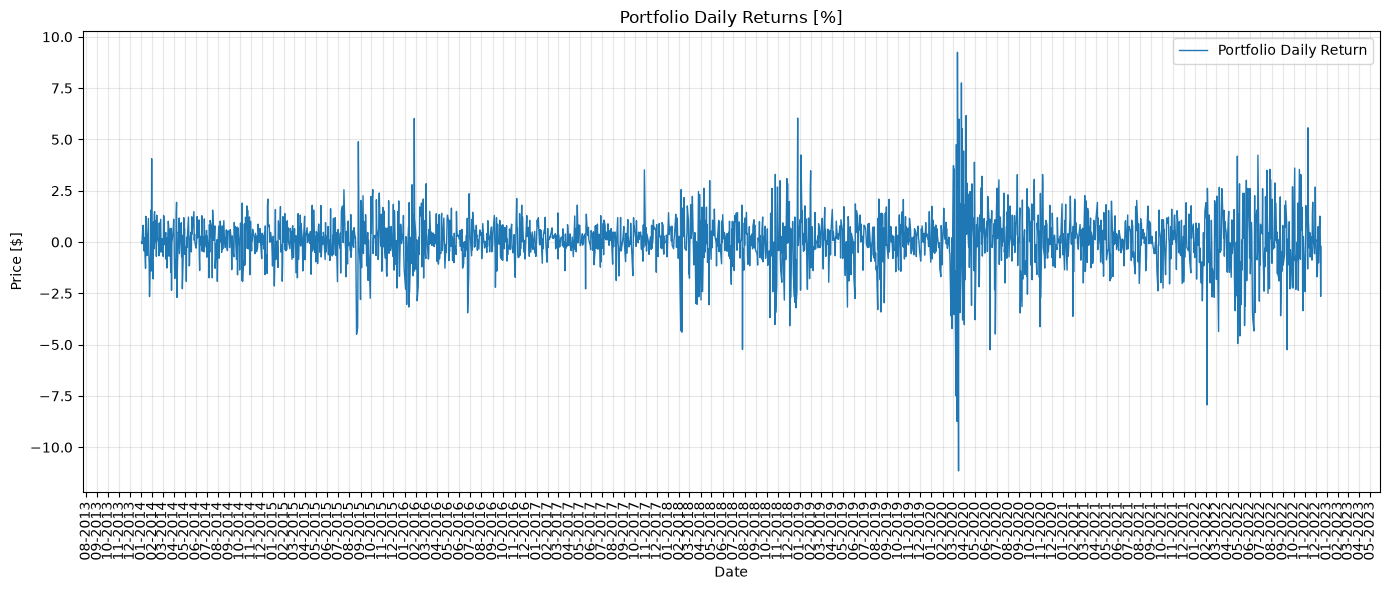

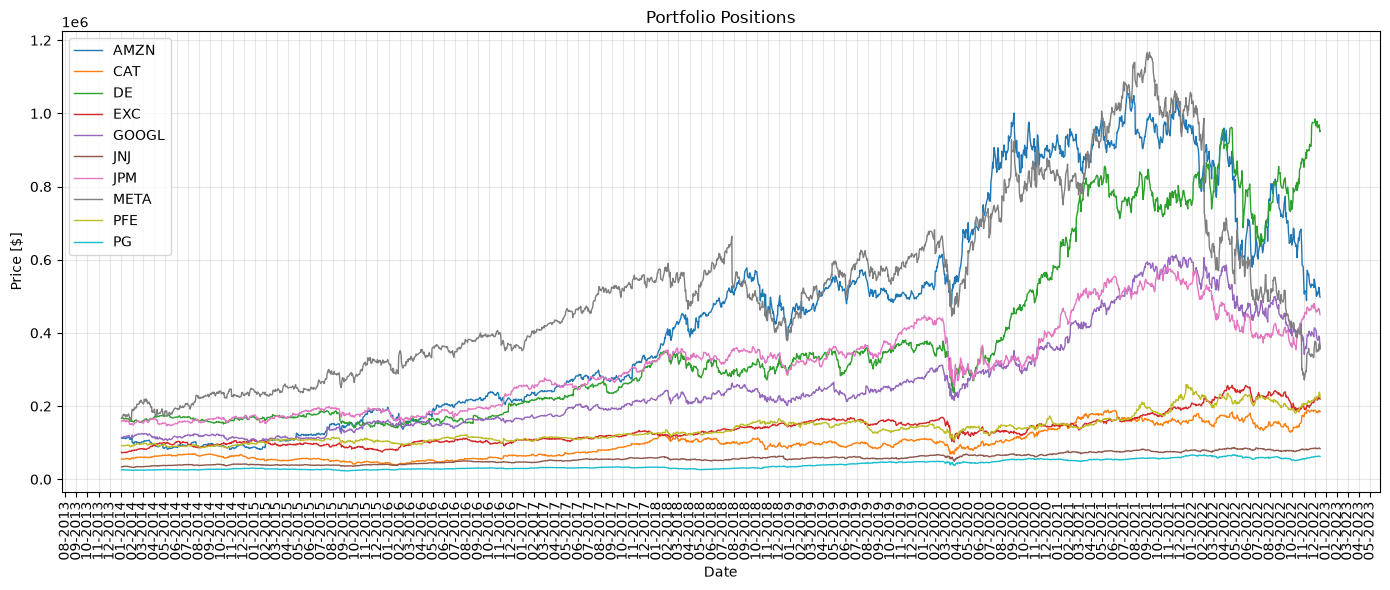

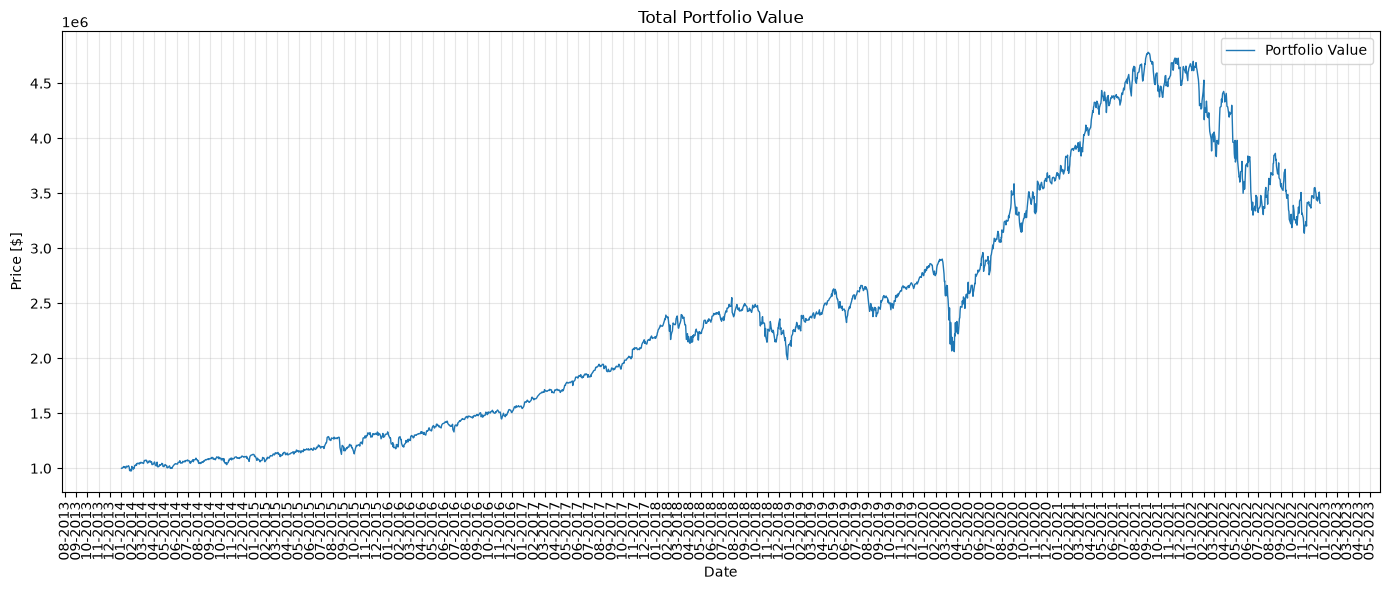

In [62]:
plot_financial_data(portfolio_df[['Date', 'Portfolio Daily Return']], 'Portfolio Daily Returns [%]')
plot_financial_data(portfolio_df.drop(['Portfolio Value', 'Portfolio Daily Return'], axis = 1), 'Portfolio Positions')

plot_financial_data(portfolio_df[['Date', 'Portfolio Value']], 'Total Portfolio Value')

### 5.9 Define the Simulation Engine Function

In [66]:
def simulation_engine(weights, initial_investment):
    portfolio_df = assest_allocation(close_price_df, weights=weights, initial_investment=initial_investment)
    
    return_on_investment = ((portfolio_df['Portfolio Value'][-1:] - portfolio_df['Portfolio Value'][0])/ portfolio_df['Portfolio Value'][0]) * 100
    
    portfolio_daily_return_df = portfolio_df.drop(columns = ['Date', 'Portfolio Value', 'Portfolio Daily Return'])
    
    portfolio_daily_return_df = portfolio_daily_return_df.pct_change(1)
    
    expected_portfolio_return = np.sum(weights * portfolio_daily_return_df.mean()) * 252
    
    covariance = portfolio_daily_return_df.cov() * 252
    expected_volatility = np.sqrt(np.dot(weights.T, np.dot(covariance, weights)))
    
    rf = 0.01
    
    sharpe_ratio = (expected_portfolio_return - rf)/expected_volatility
    return expected_portfolio_return, expected_volatility, sharpe_ratio, portfolio_df['Portfolio Value'][-1:].values[0], return_on_investment.values[0]

In [67]:
initial_investment = 1000000
portfolio_metrics = simulation_engine(weights, initial_investment)

In [68]:
print('Expected Portfolio Annual Return = {:.2f}%'.format(portfolio_metrics[0] * 100))
print('Portfolio Standard Deviation (Volatility) = {:.2f}%'.format(portfolio_metrics[1] * 100))
print('Sharpe Ratio = {:.2f}'.format(portfolio_metrics[2]))
print('Portfolio Final Value = ${:.2f}'.format(portfolio_metrics[3]))
print('Return on Investment = {:.2f}%'.format(portfolio_metrics[4]))


Expected Portfolio Annual Return = 17.43%
Portfolio Standard Deviation (Volatility) = 20.12%
Sharpe Ratio = 0.82
Portfolio Final Value = $3410135.94
Return on Investment = 241.01%


### 5.10 Monte Carlo Simulations

In [73]:
sim_runs = 10000
initial_investment = 1000000

weights_runs = np.zeros((sim_runs, n))

sharpe_ratios_runs = np.zeros(sim_runs)

expected_portfolio_returns_runs = np.zeros(sim_runs)

volatility_runs = np.zeros(sim_runs)

return_on_investment_runs = np.zeros(sim_runs)

final_value_runs = np.zeros(sim_runs)

for i in range(sim_runs):
    weights = generate_portfolio_weights(n)
    
    weights_runs[i,:] = weights
    
    expected_portfolio_returns_runs[i], volatility_runs[i], sharpe_ratios_runs[i], final_value_runs[i], return_on_investment_runs[i] = simulation_engine(weights, initial_investment)
    
    print(f"Simulation Run = {i}")
    print(f"Weights = {weights_runs[i].round(3)}, Final Value = ${final_value_runs[i]:.2f}, Sharpe Ratio = {sharpe_ratios_runs[i]:.2f}")
    print('\n')
    
print(sharpe_ratios_runs.min())


Simulation Run = 0
Weights = [0.026 0.077 0.104 0.166 0.058 0.121 0.025 0.09  0.19  0.144], Final Value = $3025297.79, Sharpe Ratio = 0.85


Simulation Run = 1
Weights = [0.177 0.125 0.005 0.041 0.2   0.031 0.071 0.024 0.19  0.135], Final Value = $3127245.33, Sharpe Ratio = 0.82


Simulation Run = 2
Weights = [0.17  0.2   0.005 0.191 0.038 0.102 0.018 0.088 0.001 0.188], Final Value = $3088901.56, Sharpe Ratio = 0.84


Simulation Run = 3
Weights = [0.09  0.142 0.119 0.016 0.158 0.141 0.121 0.116 0.032 0.066], Final Value = $3290127.69, Sharpe Ratio = 0.82


Simulation Run = 4
Weights = [0.019 0.04  0.05  0.154 0.07  0.182 0.178 0.162 0.04  0.105], Final Value = $2847118.93, Sharpe Ratio = 0.78


Simulation Run = 5
Weights = [0.065 0.05  0.073 0.154 0.182 0.124 0.06  0.095 0.173 0.024], Final Value = $3083690.82, Sharpe Ratio = 0.83


Simulation Run = 6
Weights = [0.047 0.121 0.    0.137 0.137 0.121 0.142 0.04  0.12  0.133], Final Value = $2876429.26, Sharpe Ratio = 0.81


Simulation Ru

In [71]:
sim_runs = 50
initial_investment = 1000000

weights_runs = np.zeros((sim_runs, n))

sharpe_ratios_runs = np.zeros(sim_runs)

expected_portfolio_returns_runs = np.zeros(sim_runs)

volatility_runs = np.zeros(sim_runs)

return_on_investment_runs = np.zeros(sim_runs)

final_value_runs = np.zeros(sim_runs)

for i in range(sim_runs):
    weights = generate_portfolio_weights(n)
    
    weights_runs[i,:] = weights
    
    expected_portfolio_returns_runs[i], volatility_runs[i], sharpe_ratios_runs[i], final_value_runs[i], return_on_investment_runs[i] = simulation_engine(weights, initial_investment)
    
    print(f"Simulation Run = {i}")
    print(f"Weights = {weights_runs[i].round(3)}, Final Value = ${final_value_runs[i]:.2f}, Sharpe Ratio = {sharpe_ratios_runs[i]:.2f}")
    print('\n')

print(sharpe_ratios_runs.min())

Simulation Run = 0
Weights = [0.118 0.152 0.112 0.015 0.131 0.135 0.035 0.11  0.058 0.133], Final Value = $3276899.81, Sharpe Ratio = 0.84


Simulation Run = 1
Weights = [0.019 0.088 0.039 0.111 0.187 0.111 0.12  0.168 0.156 0.002], Final Value = $2899937.97, Sharpe Ratio = 0.76


Simulation Run = 2
Weights = [0.015 0.162 0.05  0.073 0.074 0.165 0.124 0.049 0.157 0.131], Final Value = $2919317.53, Sharpe Ratio = 0.81


Simulation Run = 3
Weights = [0.074 0.155 0.061 0.034 0.184 0.213 0.057 0.005 0.067 0.149], Final Value = $3115834.36, Sharpe Ratio = 0.85


Simulation Run = 4
Weights = [0.129 0.113 0.107 0.193 0.06  0.063 0.043 0.028 0.19  0.076], Final Value = $3307813.14, Sharpe Ratio = 0.88


Simulation Run = 5
Weights = [0.151 0.045 0.144 0.08  0.111 0.149 0.005 0.035 0.193 0.087], Final Value = $3377578.29, Sharpe Ratio = 0.90


Simulation Run = 6
Weights = [0.095 0.067 0.153 0.047 0.083 0.072 0.038 0.161 0.124 0.161], Final Value = $3255619.50, Sharpe Ratio = 0.85


Simulation Ru

### 5.11 Portfolio Optimisation

In [74]:
print(sharpe_ratios_runs)
print(sharpe_ratios_runs.argmax())
print(sharpe_ratios_runs.max())
print(weights_runs)
print(weights_runs[sharpe_ratios_runs.argmax(),:])



[0.84911353 0.82023675 0.83647244 ... 0.85932073 0.86923497 0.8231269 ]
8804
0.9290651229937364
[[0.02558065 0.07723227 0.10399964 ... 0.08968448 0.19042625 0.14390105]
 [0.17707178 0.12475407 0.00527111 ... 0.02412666 0.19010675 0.13489042]
 [0.17041678 0.19972135 0.00462777 ... 0.08810028 0.00108024 0.18750519]
 ...
 [0.18413444 0.01148942 0.10082891 ... 0.04816325 0.08574992 0.12949962]
 [0.13196782 0.14043596 0.1245742  ... 0.01473294 0.0379079  0.15532784]
 [0.13878752 0.12429423 0.01625087 ... 0.1187785  0.12724246 0.06642893]]
[0.28929432 0.00997514 0.23561317 0.13800793 0.05860075 0.05351016
 0.01933996 0.00037857 0.06510741 0.13017259]


In [75]:
optimal_portfolio_return, optimal_volatility, optimal_sharpe_ratio, highest_final_value, optimal_return_on_investment = simulation_engine(weights_runs[sharpe_ratios_runs.argmax(), :], initial_investment)

In [76]:
print('Best Portfolio Metrics Based on {} Monte Carlo Simulation Runs:'.format(sim_runs))
print('  - Portfolio Expected Annual Return = {:.02f}%'.format(optimal_portfolio_return * 100))
print('  - Portfolio Standard Deviation (Volatility) = {:.02f}%'.format(optimal_volatility * 100))
print('  - Sharpe Ratio = {:.02f}'.format(optimal_sharpe_ratio))
print('  - Final Value = ${:.02f}'.format(highest_final_value))
print('  - Return on Investment = {:.02f}%'.format(optimal_return_on_investment))

Best Portfolio Metrics Based on 10000 Monte Carlo Simulation Runs:
  - Portfolio Expected Annual Return = 18.52%
  - Portfolio Standard Deviation (Volatility) = 18.86%
  - Sharpe Ratio = 0.93
  - Final Value = $3917198.92
  - Return on Investment = 291.72%


In [78]:
sim_out_df = pd.DataFrame({'Volatility': volatility_runs.tolist(), 'Portfolio_Return': expected_portfolio_returns_runs.tolist(), 'Sharpe_Ratio': sharpe_ratios_runs.tolist() })
sim_out_df

,Volatility,Portfolio_Return,Sharpe_Ratio
0,0.167348,0.152097,0.849114
1,0.183959,0.160890,0.820237
2,0.179941,0.160516,0.836472
3,0.192831,0.167658,0.817597
4,0.179377,0.150195,0.781564
...,...,...,...
9995,0.190920,0.171827,0.847617
9996,0.175654,0.165266,0.883933
9997,0.186394,0.170172,0.859321
9998,0.186005,0.171682,0.869235


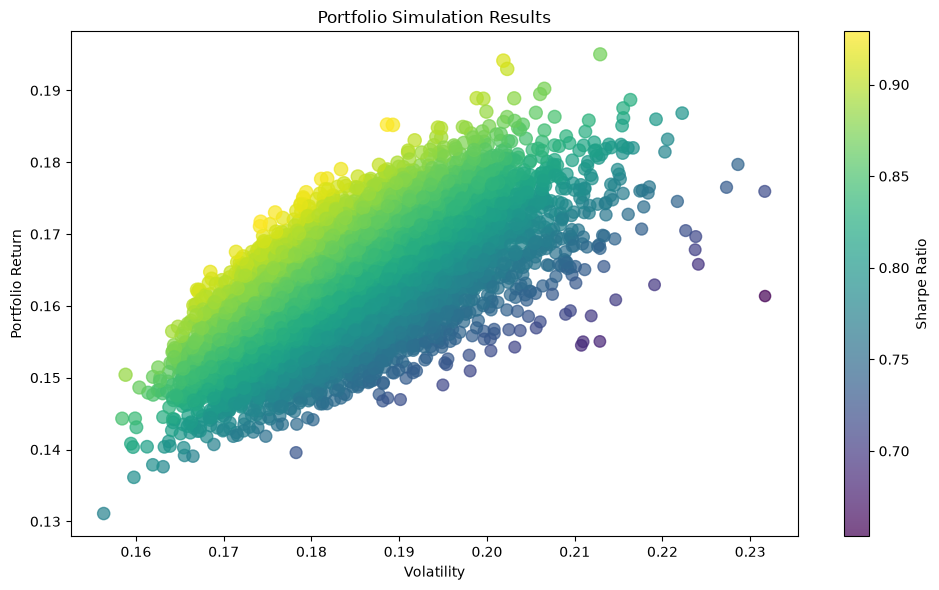

In [ ]:
# Create scatter plot
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    sim_out_df['Volatility'],
    sim_out_df['Portfolio_Return'],
    c=sim_out_df['Sharpe_Ratio'],          # color by Sharpe Ratio
    s=sim_out_df['Sharpe_Ratio'] * 100,    # size by Sharpe Ratio (adjust scale as needed)
    cmap='viridis',
    alpha=0.7
)

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Sharpe Ratio')

# Labels and styling
plt.xlabel('Volatility')
plt.ylabel('Portfolio Return')
plt.title('Portfolio Simulation Results')

# White background
plt.gca().set_facecolor('white')
plt.gcf().set_facecolor('white')

plt.tight_layout()
plt.show()

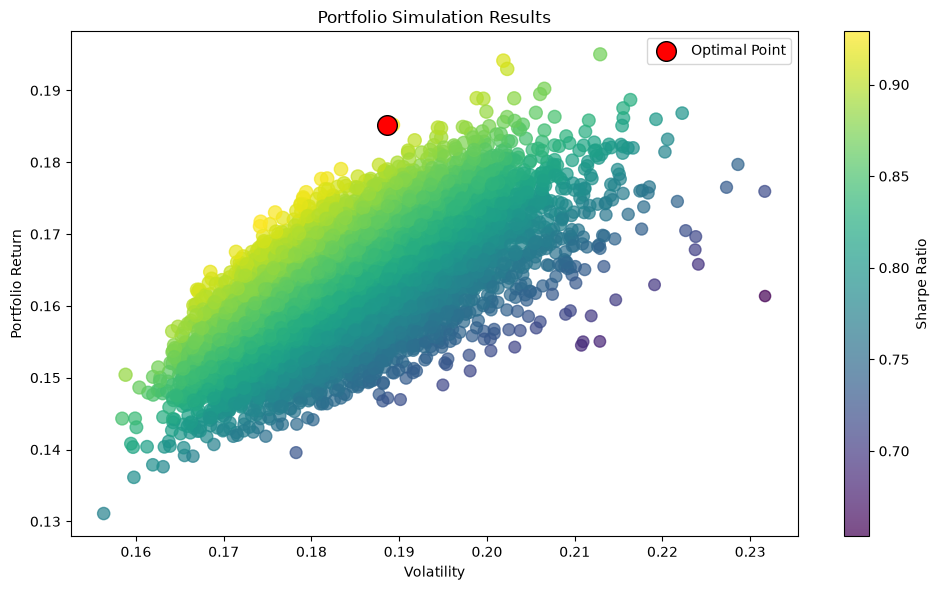

In [82]:
plt.figure(figsize=(10, 6))

# Main scatter plot
scatter = plt.scatter(
    sim_out_df['Volatility'],
    sim_out_df['Portfolio_Return'],
    c=sim_out_df['Sharpe_Ratio'],
    s=sim_out_df['Sharpe_Ratio'] * 100,  # adjust scaling if needed
    cmap='viridis',
    alpha=0.7
)

# Optimal portfolio point
plt.scatter(
    optimal_volatility,
    optimal_portfolio_return,
    color='red',
    s=200,  # similar to Plotly marker size=40
    label='Optimal Point',
    edgecolors='black'
)

# Colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Sharpe Ratio')

# Labels and formatting
plt.xlabel('Volatility')
plt.ylabel('Portfolio Return')
plt.title('Portfolio Simulation Results')
plt.legend()

# White background
plt.gca().set_facecolor('white')
plt.gcf().set_facecolor('white')

plt.tight_layout()
plt.show()